[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/scw634919-bfty/ecommerce-data-analytics-portfolio/blob/main/6-clickstream-analysis-conversion-insights/notebook/clickstream_analysis_conversion_insights.ipynb)

# Clickstream Analysis and Conversion Insights

Analyze user clickstream behavior to understand customer journeys, engagement patterns, and conversion performance.

**Business Goal:** Identify user behavior patterns, funnel drop-off points, and conversion opportunities to support better e-commerce decisions.


## 1. Import Libraries

Import libraries for clickstream analysis, data processing, and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

## 2. Load Dataset

Load clickstream data and inspect the dataset structure.

In [2]:
# 1. load data
df = pd.read_csv("e-shop clothing 2008.csv", sep=";")

## 3. Data Cleaning

Clean missing values and prepare the dataset for reliable analysis.

In [6]:
print(df.head())
print(df.columns)

   year  month  day  order  country  session ID  page 1 (main category)  \
0  2008      4    1      1       29           1                       1   
1  2008      4    1      2       29           1                       1   
2  2008      4    1      3       29           1                       2   
3  2008      4    1      4       29           1                       2   
4  2008      4    1      5       29           1                       2   

  page 2 (clothing model)  colour  location  model photography  price  \
0                     A13       1         5                  1     28   
1                     A16       1         6                  1     33   
2                      B4      10         2                  1     52   
3                     B17       6         6                  2     38   
4                      B8       4         3                  2     52   

   price 2  page  
0        2     1  
1        2     1  
2        1     1  
3        2     1  
4        1     

## 4. Exploratory Data Analysis (EDA)

Explore user behavior, traffic patterns, and engagement trends.

In [7]:
# Prepare and analyze the data for clickstream and conversion insights
# Prepare and analyze the data for clickstream and conversion insights
target_col = "page 2 (clothing model)"  # <- 반드시 실제 target에 맞게 수정

## 5. Clickstream Behavior Analysis

Analyze user actions and session-level behavior across the customer journey.

In [8]:
# Prepare and analyze the data for clickstream and conversion insights
features = ["country", "page 1 (main category)", "colour", "location", "price"]
df = df.dropna(subset=features)

## 6. Conversion Funnel Analysis

Evaluate conversion performance and identify drop-off points.

In [9]:
# Prepare and analyze the data for clickstream and conversion insights
# Prepare and analyze the data for clickstream and conversion insights
# Prepare and analyze the data for clickstream and conversion insights
df["high_price_flag"] = (df["price"] > df["price"].median()).astype(int)

## 7. Visualization & Key Insights

Visualize findings and summarize important conversion insights.

In [10]:
X = df[features]
y = df["high_price_flag"]

## 8. Business Recommendations

Provide practical recommendations to improve user engagement and conversion.

In [11]:
cat_cols = ["country", "page 1 (main category)", "colour", "location"]
num_cols = ["price"]

## 9. Conclusion

Summarize findings and possible future improvements.

In [12]:
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

In [13]:
model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(random_state=42))
])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model.fit(X_train, y_train)
pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19964
           1       1.00      1.00      1.00     13131

    accuracy                           1.00     33095
   macro avg       1.00      1.00      1.00     33095
weighted avg       1.00      1.00      1.00     33095



colour
10    52.000000
12    50.429219
3     49.280427
11    48.944822
2     46.987905
13    41.875933
6     40.566491
9     40.488656
4     40.115881
14    40.053705
Name: price, dtype: float64


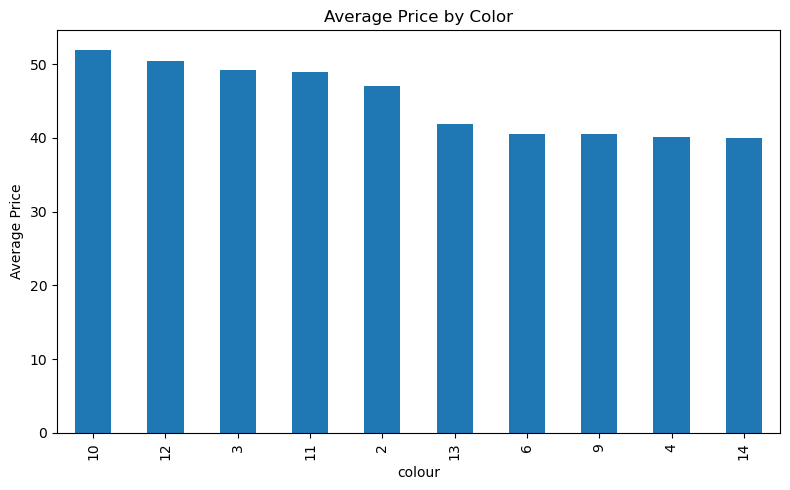

In [16]:
# simple EDA
price_by_color = df.groupby("colour")["price"].mean().sort_values(ascending=False).head(10)
print(price_by_color)

plt.figure(figsize=(8, 5))
price_by_color.plot(kind="bar")
plt.title("Average Price by Color")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()

## 10. Export CSVs for Tableau Dashboard

Export clickstream analysis results to CSV files for Tableau visualization.

In [ ]:
import os
os.makedirs("../outputs", exist_ok=True)

# Map category codes to readable labels
category_map = {1: "Trousers", 2: "Skirts", 3: "Blouses", 4: "Sale"}
df["category_name"] = df["page 1 (main category)"].map(category_map).fillna("Other")

# Average price by color (top analysis)
price_by_color = df.groupby("colour").agg(
    avg_price=("price", "mean"),
    session_count=("session ID", "nunique")
).reset_index().sort_values("avg_price", ascending=False)
price_by_color.to_csv("../outputs/price_by_color.csv", index=False)

# Traffic and pricing by product category
category_traffic = df.groupby("category_name").agg(
    session_count=("session ID", "nunique"),
    avg_price=("price", "mean"),
    high_price_pct=("high_price_flag", "mean")
).reset_index()
category_traffic["high_price_pct"] = (category_traffic["high_price_pct"] * 100).round(2)
category_traffic.to_csv("../outputs/category_traffic.csv", index=False)

# Sessions and pricing by country
country_sessions = df.groupby("country").agg(
    session_count=("session ID", "nunique"),
    avg_price=("price", "mean"),
    high_price_pct=("high_price_flag", "mean")
).reset_index().sort_values("session_count", ascending=False)
country_sessions["high_price_pct"] = (country_sessions["high_price_pct"] * 100).round(2)
country_sessions.to_csv("../outputs/country_sessions.csv", index=False)

# Price segment (Standard vs Premium) by category
price_segment = df.groupby(["category_name", "high_price_flag"]).agg(
    session_count=("session ID", "count")
).reset_index()
price_segment["price_segment"] = price_segment["high_price_flag"].map({0: "Standard", 1: "Premium"})
price_segment[["category_name", "price_segment", "session_count"]].to_csv(
    "../outputs/price_segment_by_category.csv", index=False
)

print("Saved:")
print("  ../outputs/price_by_color.csv")
print("  ../outputs/category_traffic.csv")
print("  ../outputs/country_sessions.csv")
print("  ../outputs/price_segment_by_category.csv")